In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [3]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'train.csv').exists():
            return candidate
    raise FileNotFoundError('Could not find project root with data/train.csv')


ROOT = find_project_root()
DATA_DIR = ROOT / 'data'

train = pd.read_csv(DATA_DIR / 'train.csv')
dev = pd.read_csv(DATA_DIR / 'dev.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')

train['split'] = 'train'
dev['split'] = 'dev'
test['split'] = 'test'

if 'transcription' in train.columns:
    train['transcription_str'] = train['transcription'].astype(str)
    train['transcription_len'] = train['transcription_str'].str.len()

if 'transcription' in dev.columns:
    dev['transcription_str'] = dev['transcription'].astype(str)
    dev['transcription_len'] = dev['transcription_str'].str.len()

ROOT

PosixPath('/data/tsa/itmo/ASR_TTS/group_project_1')

## 1. Первичный обзор

In [4]:
overview = pd.DataFrame([
    {
        'split': 'train',
        'rows': train.shape[0],
        'cols': train.shape[1],
        'duplicates': train.duplicated().sum(),
        'missing_values': train.isna().sum().sum(),
        'unique_files': train['filename'].nunique(),
    },
    {
        'split': 'dev',
        'rows': dev.shape[0],
        'cols': dev.shape[1],
        'duplicates': dev.duplicated().sum(),
        'missing_values': dev.isna().sum().sum(),
        'unique_files': dev['filename'].nunique(),
    },
    {
        'split': 'test',
        'rows': test.shape[0],
        'cols': test.shape[1],
        'duplicates': test.duplicated().sum(),
        'missing_values': test.isna().sum().sum(),
        'unique_files': test['filename'].nunique(),
    },
])

overview

,split,rows,cols,duplicates,missing_values,unique_files
0,train,12553,9,0,0,12553
1,dev,2265,9,0,0,2265
2,test,2582,4,0,0,2582


In [5]:
print('Train info')
train.info()
print('\nDev info')
dev.info()
print('\nTest info')
test.info()

Train info
<class 'pandas.DataFrame'>
RangeIndex: 12553 entries, 0 to 12552
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   filename           12553 non-null  str  
 1   transcription      12553 non-null  int64
 2   spk_id             12553 non-null  str  
 3   gender             12553 non-null  str  
 4   ext                12553 non-null  str  
 5   samplerate         12553 non-null  int64
 6   split              12553 non-null  str  
 7   transcription_str  12553 non-null  str  
 8   transcription_len  12553 non-null  int64
dtypes: int64(3), str(6)
memory usage: 882.8 KB

Dev info
<class 'pandas.DataFrame'>
RangeIndex: 2265 entries, 0 to 2264
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   filename           2265 non-null   str  
 1   transcription      2265 non-null   int64
 2   spk_id             2265 non-null   str  
 3 

In [6]:
train.head()

,filename,transcription,spk_id,gender,ext,samplerate,split,transcription_str,transcription_len
0,train/0007c21c23.wav,139473,spk_E,female,wav,24000,train,139473,6
1,train/000bee1b1d.wav,992597,spk_B,male,wav,24000,train,992597,6
2,train/001a718902.wav,500869,spk_A,female,wav,22050,train,500869,6
3,train/001e8e5565.wav,969908,spk_C,male,wav,22050,train,969908,6
4,train/001ee5be6b.wav,80484,spk_E,female,wav,24000,train,80484,5


In [7]:
dev.head()

,filename,transcription,spk_id,gender,ext,samplerate,split,transcription_str,transcription_len
0,dev/0025d6d9a9.wav,849905,spk_J,male,wav,16000,dev,849905,6
1,dev/0030479d60.mp3,967653,spk_I,female,mp3,16000,dev,967653,6
2,dev/003085d7a4.mp3,427524,spk_K,female,mp3,16000,dev,427524,6
3,dev/0047ca69ae.wav,93752,spk_H,male,wav,16000,dev,93752,5
4,dev/00b89e507d.mp3,43355,spk_I,female,mp3,16000,dev,43355,5


In [8]:
test.head()

,filename,ext,samplerate,split
0,test/d2440788a9.mp3,mp3,16000,test
1,test/e247dbf761.mp3,mp3,16000,test
2,test/071f4a5be7.mp3,mp3,16000,test
3,test/798bd15db7.mp3,mp3,16000,test
4,test/58c0464ad5.mp3,mp3,16000,test


## 2. Пропуски и дубликаты

In [9]:
missing_report = pd.DataFrame({
    'train_missing': train.isna().sum(),
    'dev_missing': dev.isna().sum(),
    'test_missing': test.isna().sum(),
}).fillna(0).astype(int)

missing_report

,train_missing,dev_missing,test_missing
ext,0,0,0
filename,0,0,0
gender,0,0,0
samplerate,0,0,0
spk_id,0,0,0
split,0,0,0
transcription,0,0,0
transcription_len,0,0,0
transcription_str,0,0,0


In [10]:
duplicates_report = pd.DataFrame({
    'split': ['train', 'dev', 'test'],
    'duplicate_rows': [train.duplicated().sum(), dev.duplicated().sum(), test.duplicated().sum()],
    'duplicate_filenames': [train['filename'].duplicated().sum(), dev['filename'].duplicated().sum(), test['filename'].duplicated().sum()],
})

duplicates_report

,split,duplicate_rows,duplicate_filenames
0,train,0,0
1,dev,0,0
2,test,0,0


## 3. Описательная статистика

In [11]:
train.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
filename,12553,12553,train/0007c21c23.wav,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transcription,12553.0,NaN,NaN,NaN,500423.625747,288543.897615,14.0,251006.0,497021.0,749703.0,999888.0
spk_id,12553,6,spk_E,5686,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,12553,2,female,7665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ext,12553,1,wav,12553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
samplerate,12553.0,NaN,NaN,NaN,23669.27826,731.828661,22050.0,24000.0,24000.0,24000.0,24000.0
split,12553,1,train,12553,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transcription_str,12553,12510,222162,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transcription_len,12553.0,NaN,NaN,NaN,5.888553,0.353112,2.0,6.0,6.0,6.0,6.0


In [12]:
dev.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
filename,2265,2265,dev/0025d6d9a9.wav,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transcription,2265.0,NaN,NaN,NaN,503904.978366,289999.92245,1363.0,251558.0,507286.0,753732.0,999669.0
spk_id,2265,10,spk_H,633,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,2265,2,male,1277,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ext,2265,2,wav,1577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
samplerate,2265.0,NaN,NaN,NaN,16000.0,0.0,16000.0,16000.0,16000.0,16000.0,16000.0
split,2265,1,dev,2265,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transcription_str,2265,2261,632952,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
transcription_len,2265.0,NaN,NaN,NaN,5.891832,0.341801,4.0,6.0,6.0,6.0,6.0


In [13]:
test.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
filename,2582,2582,test/d2440788a9.mp3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ext,2582,2,wav,1770,NaN,NaN,NaN,NaN,NaN,NaN,NaN
samplerate,2582.0,NaN,NaN,NaN,16000.0,0.0,16000.0,16000.0,16000.0,16000.0,16000.0
split,2582,1,test,2582,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Категориальные признаки

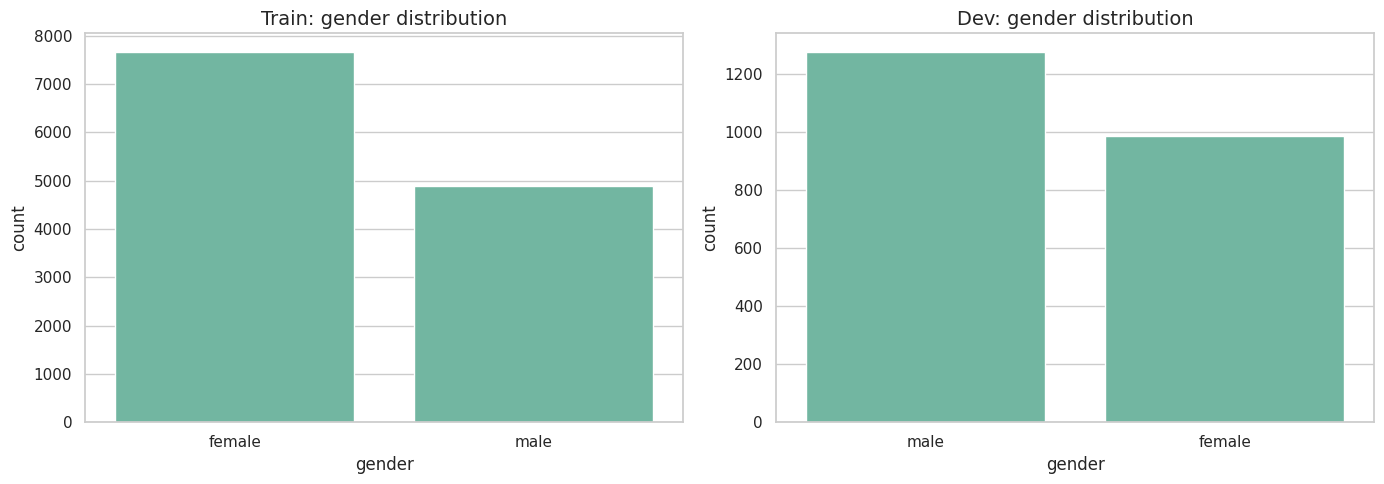

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=train, x='gender', ax=axes[0])
axes[0].set_title('Train: gender distribution')

sns.countplot(data=dev, x='gender', ax=axes[1])
axes[1].set_title('Dev: gender distribution')

plt.tight_layout()
plt.show()

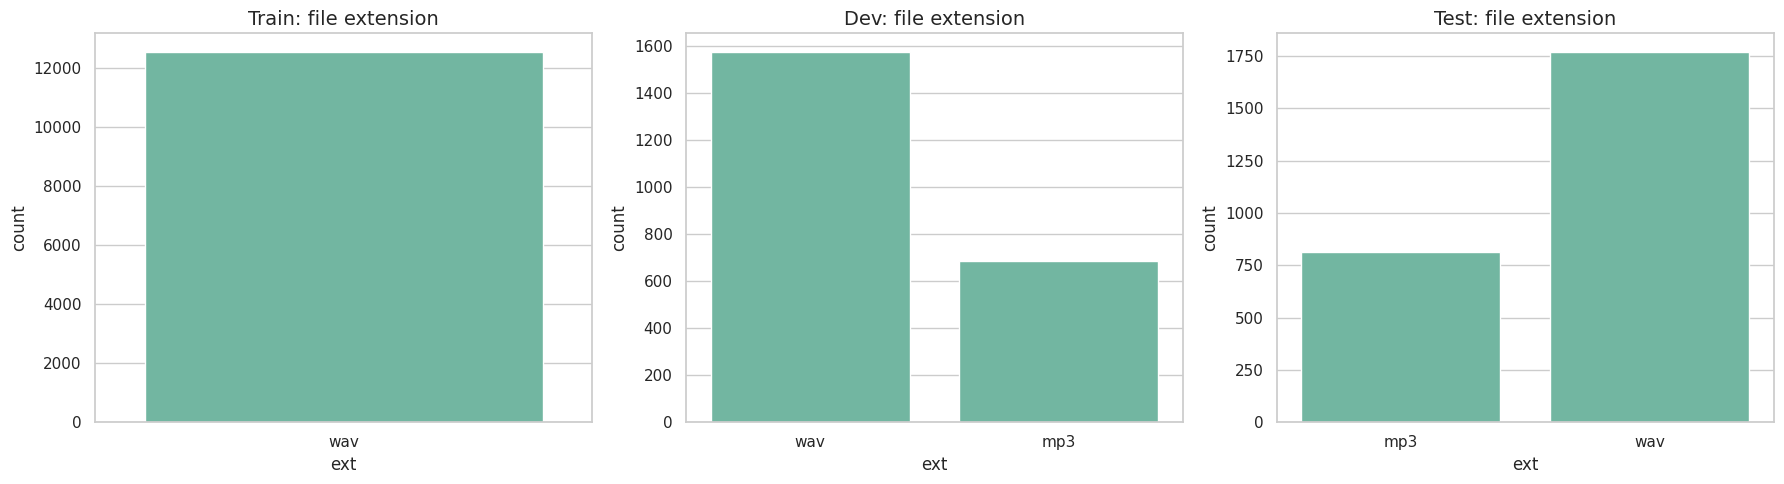

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=train, x='ext', ax=axes[0])
axes[0].set_title('Train: file extension')

sns.countplot(data=dev, x='ext', ax=axes[1])
axes[1].set_title('Dev: file extension')

sns.countplot(data=test, x='ext', ax=axes[2])
axes[2].set_title('Test: file extension')

plt.tight_layout()
plt.show()

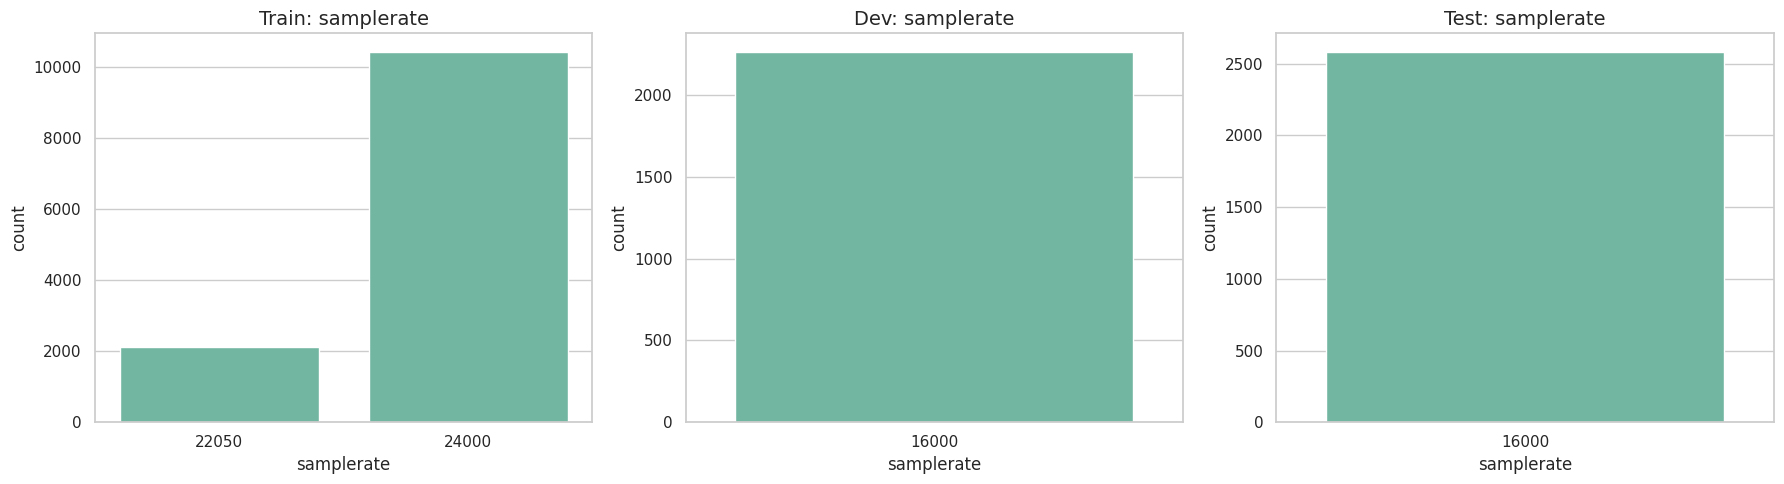

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=train, x='samplerate', ax=axes[0])
axes[0].set_title('Train: samplerate')

sns.countplot(data=dev, x='samplerate', ax=axes[1])
axes[1].set_title('Dev: samplerate')

sns.countplot(data=test, x='samplerate', ax=axes[2])
axes[2].set_title('Test: samplerate')

plt.tight_layout()
plt.show()

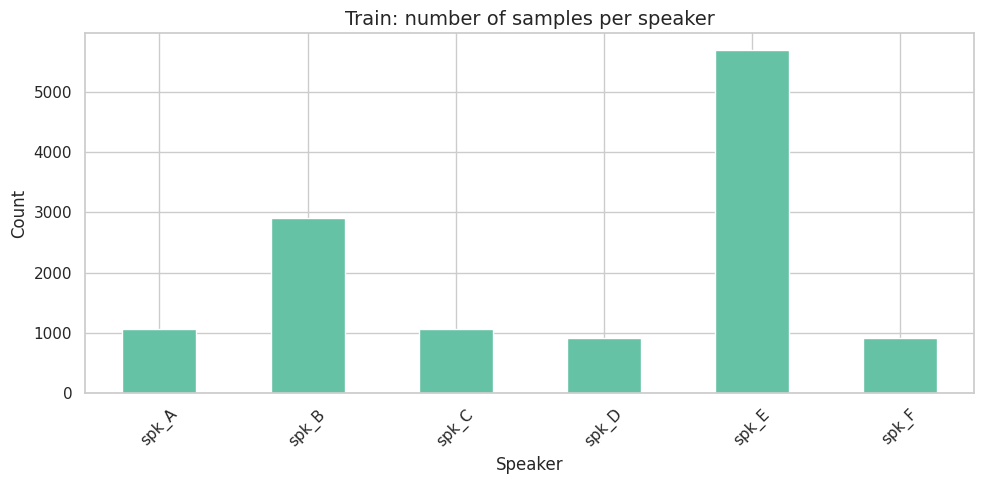

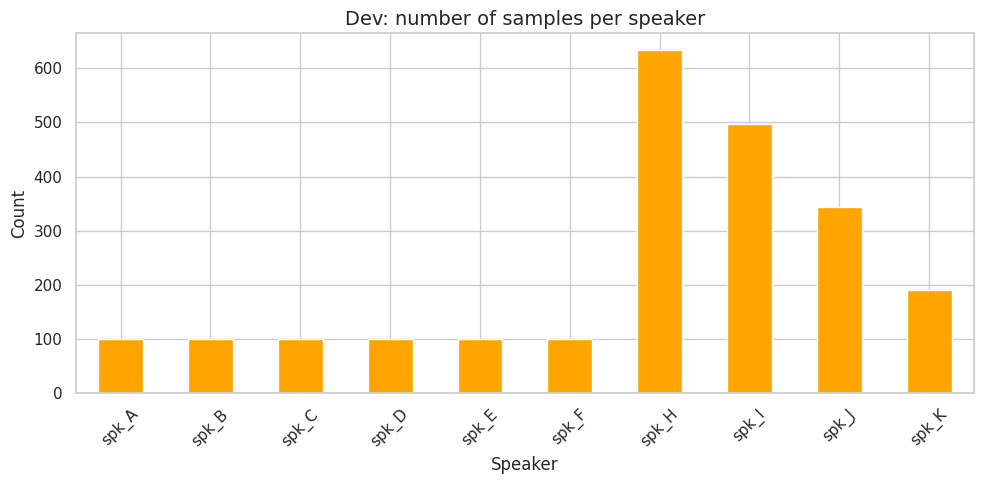

In [17]:
plt.figure(figsize=(10, 5))
train['spk_id'].value_counts().sort_index().plot(kind='bar')
plt.title('Train: number of samples per speaker')
plt.xlabel('Speaker')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
dev['spk_id'].value_counts().sort_index().plot(kind='bar', color='orange')
plt.title('Dev: number of samples per speaker')
plt.xlabel('Speaker')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Анализ транскрипций

In [18]:
transcription_stats = pd.DataFrame([
    {
        'split': 'train',
        'unique_transcriptions': train['transcription'].nunique(),
        'min_len': train['transcription_len'].min(),
        'mean_len': train['transcription_len'].mean(),
        'median_len': train['transcription_len'].median(),
        'max_len': train['transcription_len'].max(),
    },
    {
        'split': 'dev',
        'unique_transcriptions': dev['transcription'].nunique(),
        'min_len': dev['transcription_len'].min(),
        'mean_len': dev['transcription_len'].mean(),
        'median_len': dev['transcription_len'].median(),
        'max_len': dev['transcription_len'].max(),
    },
])

transcription_stats

,split,unique_transcriptions,min_len,mean_len,median_len,max_len
0,train,12510,2,5.888553,6.0,6
1,dev,2261,4,5.891832,6.0,6


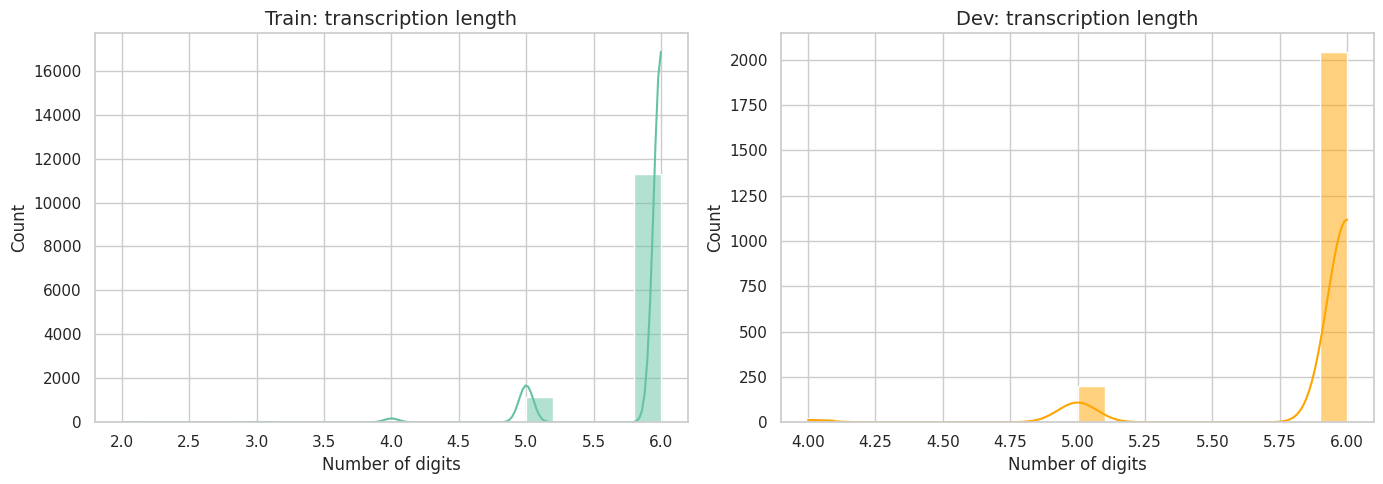

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train['transcription_len'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Train: transcription length')
axes[0].set_xlabel('Number of digits')

sns.histplot(dev['transcription_len'], bins=20, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Dev: transcription length')
axes[1].set_xlabel('Number of digits')

plt.tight_layout()
plt.show()

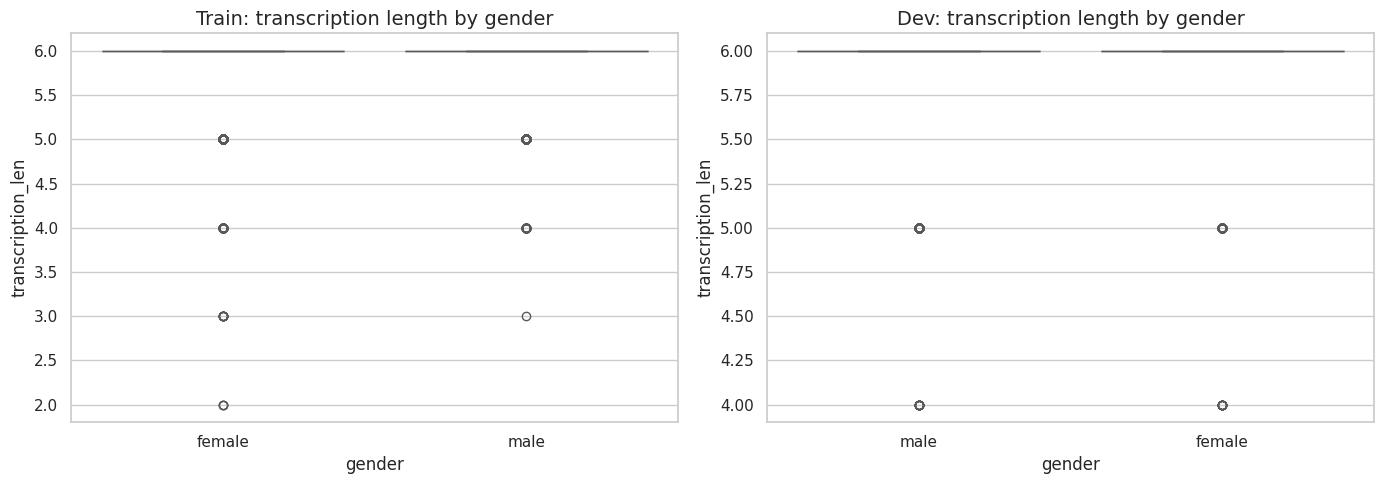

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=train, x='gender', y='transcription_len', ax=axes[0])
axes[0].set_title('Train: transcription length by gender')

sns.boxplot(data=dev, x='gender', y='transcription_len', ax=axes[1])
axes[1].set_title('Dev: transcription length by gender')

plt.tight_layout()
plt.show()

## 6. Сравнение train / dev / test

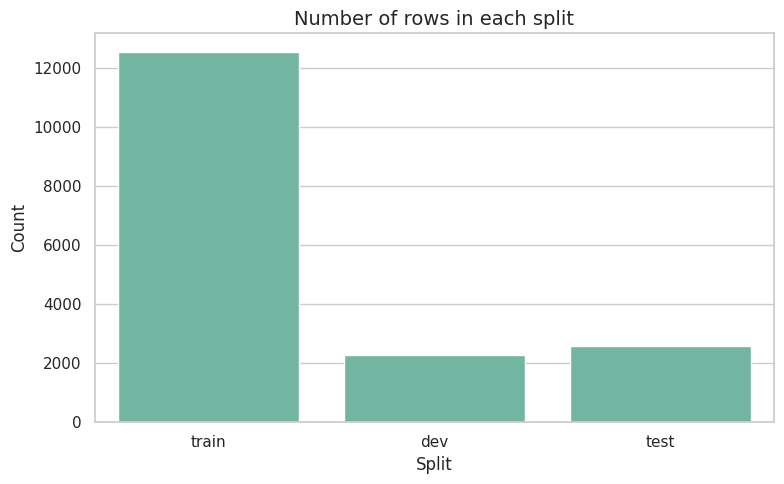

In [21]:
split_size = pd.concat([
    train[['filename', 'ext', 'samplerate', 'split']],
    dev[['filename', 'ext', 'samplerate', 'split']],
    test[['filename', 'ext', 'samplerate', 'split']],
], ignore_index=True)

plt.figure(figsize=(8, 5))
sns.countplot(data=split_size, x='split', order=['train', 'dev', 'test'])
plt.title('Number of rows in each split')
plt.xlabel('Split')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

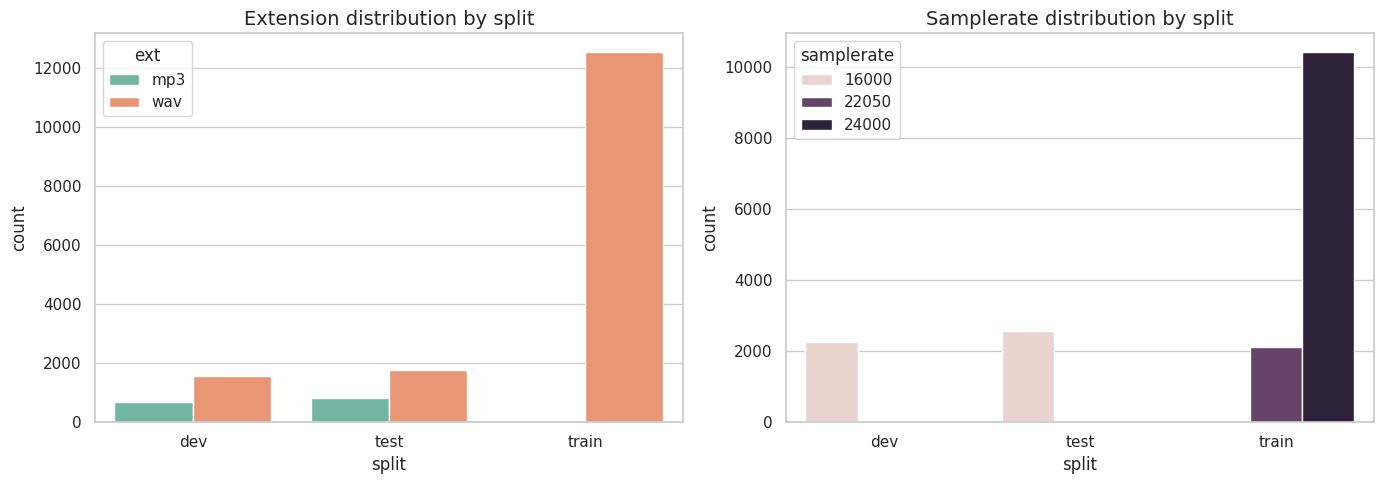

In [22]:
ext_compare = split_size.groupby(['split', 'ext']).size().reset_index(name='count')
sr_compare = split_size.groupby(['split', 'samplerate']).size().reset_index(name='count')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=ext_compare, x='split', y='count', hue='ext', ax=axes[0])
axes[0].set_title('Extension distribution by split')

sns.barplot(data=sr_compare, x='split', y='count', hue='samplerate', ax=axes[1])
axes[1].set_title('Samplerate distribution by split')

plt.tight_layout()
plt.show()

In [23]:
summary_notes = [
    f"Train rows: {len(train)}",
    f"Dev rows: {len(dev)}",
    f"Test rows: {len(test)}",
    f"Train speakers: {train['spk_id'].nunique()}",
    f"Dev speakers: {dev['spk_id'].nunique()}",
    f"Train samplerates: {sorted(train['samplerate'].unique().tolist())}",
    f"Dev samplerates: {sorted(dev['samplerate'].unique().tolist())}",
    f"Test samplerates: {sorted(test['samplerate'].unique().tolist())}",
    f"Train extensions: {train['ext'].value_counts().to_dict()}",
    f"Dev extensions: {dev['ext'].value_counts().to_dict()}",
    f"Test extensions: {test['ext'].value_counts().to_dict()}",
]

for note in summary_notes:
    print('-', note)

- Train rows: 12553
- Dev rows: 2265
- Test rows: 2582
- Train speakers: 6
- Dev speakers: 10
- Train samplerates: [22050, 24000]
- Dev samplerates: [16000]
- Test samplerates: [16000]
- Train extensions: {'wav': 12553}
- Dev extensions: {'wav': 1577, 'mp3': 688}
- Test extensions: {'wav': 1770, 'mp3': 812}
